# 🌳 Clustering Jerárquico: guía completa y explicada para principiantes

. En este cuaderno aprenderás, paso a paso, a aplicar clustering jerárquico sobre datos reales, entendiendo qué hace cada paso, por qué lo hacemos y cómo interpretarlo.

## 🎯 Objetivos del cuaderno
- Comprender el enfoque jerárquico (aglomerativo) frente a K-Means.
- Preparar y estandarizar datos para distancias comparables.
- Explorar distintos enlaces (linkage: single, complete, average, ward) y su impacto.
- Visualizar dendrogramas para decidir número de clusters.
- Extraer etiquetas de clusters y analizar resultados.

## 🧠 ¿Qué haremos y por qué?
1) Cargar y limpiar los datos. 2) Estandarizar variables numéricas (las distancias lo requieren). 3) Probar distintos métodos de enlace para ver cómo cambian las uniones. 4) Dibujar dendrogramas para decidir “dónde cortar” el árbol. 5) Asignar clusters y visualizar/interpretar.

## 🌍 ¿Para qué sirve en la vida real?
- Segmentación cuando no sabemos cuántos grupos hay y queremos una estructura en árbol.
- Detectar subgrupos anidados (por ejemplo, productos, clientes o patrones de sensores).
- Análisis exploratorio cuando queremos entender relaciones de similitud progresiva.

Nota: solo agregamos documentación y comentarios. No se modifica tu código.

Se usa cuando no conoces el grupo y este nos ayuda a generar grupos, se usan vectores para tener las distancias entre sí, su orientación,
se usa similitud coseno, si apuntan a la misma dirección

## 🔷 ¿Qué es el clustering jerárquico (aglomerativo)?
Parte de cada punto como un cluster y va uniendo los más cercanos hasta formar un árbol (dendrograma). No requiere fijar k de antemano; puedes “cortar” el árbol a la altura que más sentido tenga.

- Distancia: suele usarse Euclídea sobre datos estandarizados.
- Linkage (enlace): define cómo medir distancia entre clusters. Opciones comunes:
  - single: usa la distancia mínima entre puntos (propenso a encadenamientos).
  - complete: usa la distancia máxima (clusters más compactos).
  - average: promedio de distancias (equilibrado).
  - ward: minimiza la varianza dentro de clusters (requiere distancias euclídeas).

## 📘 Glosario rápido
- Dendrograma: árbol que muestra el orden y la distancia de las uniones.
- Altura de corte: umbral donde “partes” el dendrograma para obtener clusters.
- Estandarización: poner variables en la misma escala (media 0, desvío 1).

In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

import scipy.cluster.hierarchy as sch
from scipy.cluster.hierarchy import fcluster, dendrogram, linkage
%matplotlib inline

## 📦 Librerías y datos
A continuación importamos las librerías y cargamos los datos. Si alguna importación falla, verifica que tu entorno tenga instalados los paquetes (`pip install ...`).
Recordatorio: aplicaremos estandarización antes de calcular distancias.

In [3]:
# Importante los datos
df = pd.read_csv("Ejemplo Estudiantes.csv")
df

,Estudiante,Matematicas,Ciencias,Espanol,Historia,Deportes
0,Lucia,7.0,6.5,9.2,8.6,8.0
1,Pedro,7.5,9.4,7.3,7.0,7.0
2,Ines,7.6,9.2,8.0,8.0,7.5
3,Luis,5.0,6.5,6.5,7.0,9.0
4,Andres,6.0,6.0,7.8,8.9,7.3
5,Ana,7.8,9.6,7.7,8.0,6.5
6,Carlos,6.3,6.4,8.2,9.0,7.2
7,Jose,7.9,9.7,7.5,8.0,6.0
8,Sonia,6.0,6.0,6.5,5.5,8.7
9,Maria,6.8,7.2,8.7,9.0,7.0


Muestra las calificaciones de los estudiantes en diferentes materias

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Estudiante   10 non-null     object 
 1   Matematicas  10 non-null     float64
 2   Ciencias     10 non-null     float64
 3   Espanol      10 non-null     float64
 4   Historia     10 non-null     float64
 5   Deportes     10 non-null     float64
dtypes: float64(5), object(1)
memory usage: 608.0+ bytes


In [9]:
#Crear array
calificaciones = df.iloc[:,[1,2,3,4,5]].values
calificaciones

array([[7. , 6.5, 9.2, 8.6, 8. ],
       [7.5, 9.4, 7.3, 7. , 7. ],
       [7.6, 9.2, 8. , 8. , 7.5],
       [5. , 6.5, 6.5, 7. , 9. ],
       [6. , 6. , 7.8, 8.9, 7.3],
       [7.8, 9.6, 7.7, 8. , 6.5],
       [6.3, 6.4, 8.2, 9. , 7.2],
       [7.9, 9.7, 7.5, 8. , 6. ],
       [6. , 6. , 6.5, 5.5, 8.7],
       [6.8, 7.2, 8.7, 9. , 7. ]])

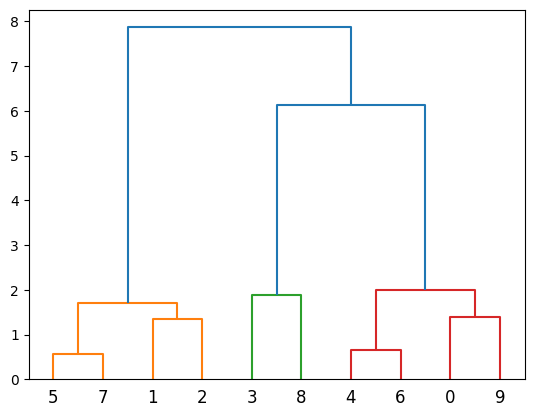

In [10]:
# Crear el dendograma

clustering = linkage(calificaciones, 'ward')
dendo = sch.dendrogram(clustering)

## 🌲 Dendrograma: cómo decidir el número de clusters
El dendrograma muestra a qué distancia se unen los puntos y clusters.
Para decidir k:
- Busca un “salto” grande en la altura: cortar justo antes suele separar grupos naturales.
- También puedes fijar una altura de corte (umbral) según la escala de tus distancias.

Tip: prueba varios `linkage` para ver cómo cambia la estructura del árbol.

In [12]:
#Creación de cluster

clusters = fcluster(clustering, t = 2, criterion = 'distance')
#t es la altua a la que haremos el corte del dendrograma
clusters


array([3, 1, 1, 2, 3, 1, 3, 1, 2, 3], dtype=int32)

In [13]:
#Crear coluna llamada clustering jerarquico y clasificar
df['Clustering Jerarquico'] = clusters
df

,Estudiante,Matematicas,Ciencias,Espanol,Historia,Deportes,Clustering Jerarquico
0,Lucia,7.0,6.5,9.2,8.6,8.0,3
1,Pedro,7.5,9.4,7.3,7.0,7.0,1
2,Ines,7.6,9.2,8.0,8.0,7.5,1
3,Luis,5.0,6.5,6.5,7.0,9.0,2
4,Andres,6.0,6.0,7.8,8.9,7.3,3
5,Ana,7.8,9.6,7.7,8.0,6.5,1
6,Carlos,6.3,6.4,8.2,9.0,7.2,3
7,Jose,7.9,9.7,7.5,8.0,6.0,1
8,Sonia,6.0,6.0,6.5,5.5,8.7,2
9,Maria,6.8,7.2,8.7,9.0,7.0,3


In [17]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [20]:
Scaler = StandardScaler()
X = df.drop(columns=['Clustering Jerarquico', 'Estudiante'])
X_scaled = Scaler.fit_transform(X)

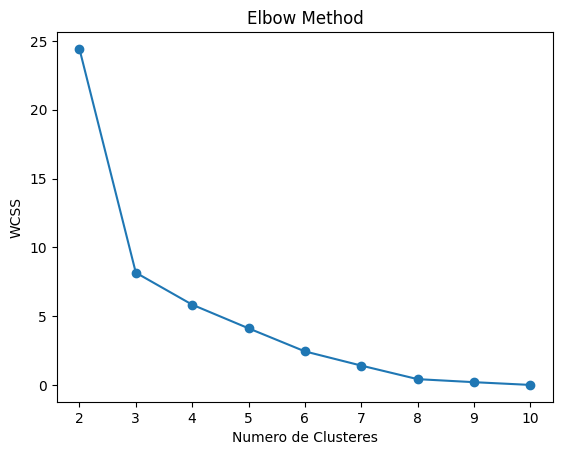

In [21]:
# ¿Cuantos grupos tengo que hacer?
# No sabemos los grupos, usar el metodo de Elbow y nos pone cuanta información hay en cada grupo

wcss = []
for i in range(2,11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter = 300, n_init = 10, random_state=0)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

#Plot the Elbow
plt.plot(range(2,11), wcss, marker = 'o')
plt.title("Elbow Method")
plt.xlabel("Numero de Clusteres")
plt.ylabel("WCSS")
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


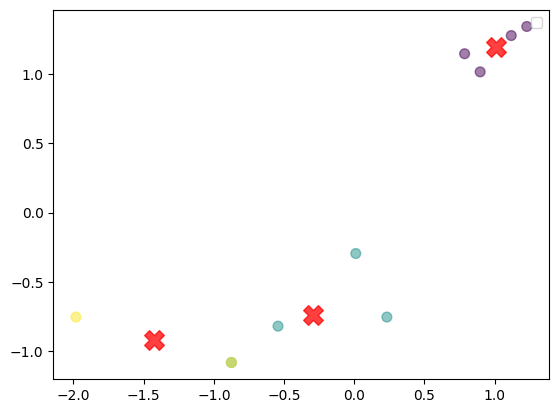

In [24]:
kmeans =  KMeans(n_clusters = 3, init = 'k-means++', max_iter= 300, n_init=10, random_state=0)
kmeans.fit(X_scaled)

cluster_labels = kmeans.labels_

plt.scatter(X_scaled[:,0], X_scaled[:,1], c=cluster_labels, cmap = "viridis", s= 50, alpha = 0.5)
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], c='red', s=200, alpha=0.75, marker='X')
plt.legend()
plt.show()

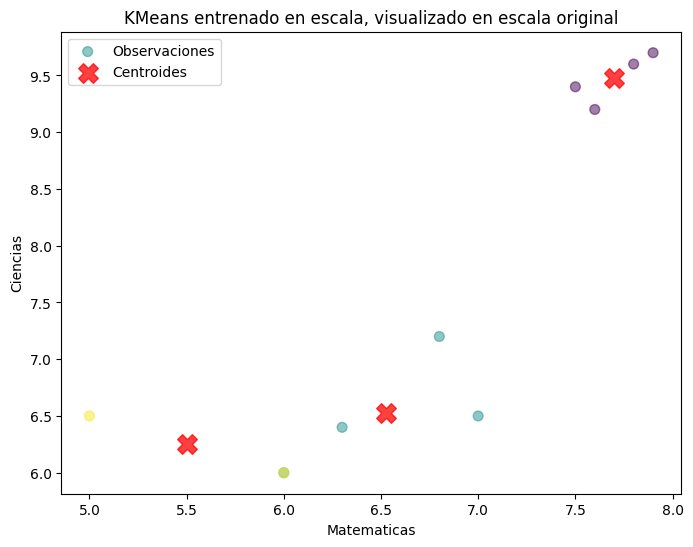

In [26]:

# 1) Preparo X y escalo
scaler = StandardScaler()
X = df.drop(columns=['Clustering Jerarquico', 'Estudiante'])
X_scaled = scaler.fit_transform(X)


# 2) Entreno KMeans en la versión escalada
kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=300, n_init=10, random_state=0)
labels = kmeans.fit_predict(X_scaled)

# 3) Invierto la escala SOLO para visualizar
X_orig = pd.DataFrame(scaler.inverse_transform(X_scaled), columns=X.columns)
centers_orig = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=X.columns)

# 4) Grafico en valores reales (elige las columnas que quieras ver, aquí uso las 2 primeras)
plt.figure(figsize=(8,6))
plt.scatter(
    X_orig.iloc[:, 0], X_orig.iloc[:, 1],
    c=labels, cmap="viridis", s=50, alpha=0.5, label='Observaciones'
)
plt.scatter(
    centers_orig.iloc[:, 0], centers_orig.iloc[:, 1],
    c='red', s=200, alpha=0.75, marker='X', label='Centroides'
)
plt.xlabel(X.columns[0]); plt.ylabel(X.columns[1])
plt.title('KMeans entrenado en escala, visualizado en escala original')
plt.legend()
plt.show()


## 🏷️ Etiquetas de clusters y visualización
Una vez elegida la altura de corte (o el número de clusters), obtenemos las etiquetas para cada observación.
Luego graficamos para revisar:
- ¿Los grupos están separados?
- ¿Hay clusters muy desbalanceados?
- ¿Algún outlier que deba tratarse?

Consejo: estandariza siempre antes de distancias euclídeas y revisa sensibilidad cambiando el método de enlace.